# 09 Distributed Training Walkthrough

This notebook explains how nanochat scales training across multiple GPUs.

The real 8-GPU path in [`runs/speedrun.sh`](../runs/speedrun.sh) is:

```text
torchrun starts 8 Python processes
    -> each process gets one rank and one local CUDA device
    -> each rank reads a different shard of data
    -> each rank computes gradients on its own micro-batch
    -> gradient accumulation builds the requested total token batch
    -> the custom distributed optimizer synchronizes updates
    -> rank 0 saves model/meta, all ranks save optimizer shards
```

Important naming note: nanochat often calls this `ddp`, but it does **not** wrap the model in PyTorch's `torch.nn.parallel.DistributedDataParallel`. It uses `torchrun` plus a distributed process group, and synchronization happens mainly inside nanochat's custom distributed optimizer, [`DistMuonAdamW`](../nanochat/optim.py). The actual switch is in [`GPT.setup_optimizer(...)`](../nanochat/gpt.py#L374-L414): `Factory = DistMuonAdamW if ddp else MuonAdamW`.

First, this notebook finds the repo root and optionally loads copied-back RunPod artifacts from `nanochat-artifacts/`. Those artifacts are not required to understand the code flow, but when they exist they let later cells use your real d24 batch settings, checkpoint files, and logs instead of made-up numbers.

In [25]:
from pathlib import Path
import json
import os
import re

repo_root = Path.cwd()
if not ((repo_root / "nanochat").exists() and (repo_root / "pyproject.toml").exists()):
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "nanochat").exists() and (candidate / "pyproject.toml").exists():
            repo_root = candidate
            break

os.chdir(repo_root)
artifact_root = Path(os.environ.get("NANOCHAT_ARTIFACTS_DIR", repo_root / "nanochat-artifacts")).expanduser()

base_meta_path = artifact_root / "base_checkpoints" / "d24" / "meta_005568.json"

base_meta = json.loads(base_meta_path.read_text()) if base_meta_path.exists() else None

print(f"repo root:     {repo_root}")
print(f"artifact root: {artifact_root} (exists={artifact_root.exists()})")
print(f"base meta:     {base_meta_path if base_meta else 'not found'}")

repo root:     /Users/eugene/Developer/nanochat
artifact root: /Users/eugene/Developer/nanochat/nanochat-artifacts (exists=True)
base meta:     /Users/eugene/Developer/nanochat/nanochat-artifacts/base_checkpoints/d24/meta_005568.json


## Step 1. `torchrun` Starts One Process Per GPU

The speedrun does **not** launch every command with `torchrun`.

Single-process setup commands do things like download data, train the tokenizer, evaluate the tokenizer, and write the final report. The expensive model stages use `torchrun` so they can use all 8 GPUs.

One distributed launch looks like this:

```bash
torchrun --standalone --nproc_per_node=8 -m scripts.base_train -- \
  --depth=24 --target-param-data-ratio=8 --device-batch-size=16 --fp8 --run=$WANDB_RUN
```

See [`runs/speedrun.sh`](../runs/speedrun.sh#L77-L90).

`torchrun` starts 8 independent Python processes. Each process receives environment variables like:

```text
RANK        global process id: 0..7
LOCAL_RANK  GPU id on this machine: 0..7
WORLD_SIZE  total number of processes: 8
```

In a single-node 8-GPU RunPod, `RANK` and `LOCAL_RANK` are usually the same number.

Once `torchrun` creates these processes, the next question is how each Python process turns its env vars into a concrete CUDA device.

In [26]:
speedrun_path = repo_root / "runs" / "speedrun.sh"
purpose_by_script = {
    "scripts.base_train": "pretrain GPT on token batches",
    "scripts.base_eval": "evaluate base checkpoint",
    "scripts.chat_sft": "supervised fine-tune chat model",
    "scripts.chat_eval": "evaluate chat checkpoint",
}

rows = []
for line_no, line in enumerate(speedrun_path.read_text().splitlines(), start=1):
    if "torchrun" not in line or line.lstrip().startswith("#"):
        continue
    script = re.search(r"-m\s+([^\s]+)", line).group(1)
    nproc = re.search(r"--nproc_per_node=(\d+)", line).group(1)
    purpose = purpose_by_script.get(script, "distributed nanochat command")
    rows.append((str(line_no), script, nproc, purpose))

headers = ("line", "script", "processes", "purpose")
widths = [max(len(row[i]) for row in [headers, *rows]) for i in range(len(headers))]

print("distributed launches found in runs/speedrun.sh")
print(f"{headers[0]:>{widths[0]}} | {headers[1]:<{widths[1]}} | {headers[2]:>{widths[2]}} | {headers[3]}")
print(f"{'-' * widths[0]}-+-{'-' * widths[1]}-+-{'-' * widths[2]}-+-{'-' * widths[3]}")
for line_no, script, nproc, purpose in rows:
    print(f"{line_no:>{widths[0]}} | {script:<{widths[1]}} | {nproc:>{widths[2]}} | {purpose}")

distributed launches found in runs/speedrun.sh
line | script             | processes | purpose
-----+--------------------+-----------+--------------------------------
  77 | scripts.base_train |         8 | pretrain GPT on token batches
  79 | scripts.base_eval  |         8 | evaluate base checkpoint
  89 | scripts.chat_sft   |         8 | supervised fine-tune chat model
  90 | scripts.chat_eval  |         8 | evaluate chat checkpoint


## Step 2. `compute_init(...)` Turns Ranks Into Devices

[`nanochat/common.py`](../nanochat/common.py#L136-L208) is the shared entry point used by base training, SFT, RL, eval, CLI, and web chat.

The connection is:

```text
runs/speedrun.sh
  -> torchrun --nproc_per_node=8 -m scripts.base_train
  -> torchrun starts 8 Python processes
  -> torchrun sets RANK, LOCAL_RANK, WORLD_SIZE in each process
  -> each process runs scripts/base_train.py
  -> scripts/base_train.py calls compute_init(device_type)
  -> compute_init(...) reads those env vars and picks cuda:LOCAL_RANK
```

So `runs/speedrun.sh` is connected to `compute_init(...)` through `torchrun` and the environment variables it creates.

The relevant logic is:

```python
is_ddp_requested = all(k in os.environ for k in ("RANK", "LOCAL_RANK", "WORLD_SIZE"))

if is_ddp_requested and device_type == "cuda":
    device = torch.device("cuda", ddp_local_rank)
    torch.cuda.set_device(device)
    dist.init_process_group(backend="nccl", device_id=device)
else:
    device = torch.device(device_type)
```

So without `torchrun`, nanochat behaves like rank 0 of world size 1. With `torchrun`, each process gets a rank and `compute_init(...)` maps that rank to one CUDA device.

Now every process knows its rank and device. The next issue is deciding which work should happen on every rank and which work should happen only once.

In [27]:
speedrun_line = next(
    (line_no, line.strip())
    for line_no, line in enumerate(speedrun_path.read_text().splitlines(), start=1)
    if "torchrun" in line and "scripts.base_train" in line and not line.lstrip().startswith("#")
)
line_no, launch_command = speedrun_line
world_size = int(re.search(r"--nproc_per_node=(\d+)", launch_command).group(1))

print("Connection chain:")
print(f"1. runs/speedrun.sh:{line_no} launches: {launch_command}")
print(f"2. torchrun starts {world_size} Python processes")
print("3. each process runs scripts.base_train")
print("4. scripts.base_train calls compute_init(device_type)")
print("5. compute_init reads torchrun env vars and picks cuda:LOCAL_RANK")
print()

headers = ("process", "RANK", "LOCAL_RANK", "WORLD_SIZE", "compute_init result")
rows = []
for rank in range(world_size):
    rows.append((
        f"process {rank}",
        str(rank),
        str(rank),
        str(world_size),
        f"device=cuda:{rank}, ddp=True",
    ))

widths = [max(len(row[i]) for row in [headers, *rows]) for i in range(len(headers))]
print("Example env created by torchrun:")
print(" | ".join(f"{headers[i]:<{widths[i]}}" for i in range(len(headers))))
print("-+-".join("-" * width for width in widths))
for row in rows:
    print(" | ".join(f"{row[i]:<{widths[i]}}" for i in range(len(row))))

print("\nNotebook note: this cell does not call compute_init() because that would initialize CUDA/NCCL.")
print("It simulates the env vars torchrun would create on the 8-GPU RunPod run.")

Connection chain:
1. runs/speedrun.sh:77 launches: torchrun --standalone --nproc_per_node=8 -m scripts.base_train -- --depth=24 --target-param-data-ratio=8 --device-batch-size=16 --fp8 --run=$WANDB_RUN
2. torchrun starts 8 Python processes
3. each process runs scripts.base_train
4. scripts.base_train calls compute_init(device_type)
5. compute_init reads torchrun env vars and picks cuda:LOCAL_RANK

Example env created by torchrun:
process   | RANK | LOCAL_RANK | WORLD_SIZE | compute_init result    
----------+------+------------+------------+------------------------
process 0 | 0    | 0          | 8          | device=cuda:0, ddp=True
process 1 | 1    | 1          | 8          | device=cuda:1, ddp=True
process 2 | 2    | 2          | 8          | device=cuda:2, ddp=True
process 3 | 3    | 3          | 8          | device=cuda:3, ddp=True
process 4 | 4    | 4          | 8          | device=cuda:4, ddp=True
process 5 | 5    | 5          | 8          | device=cuda:5, ddp=True
process 6 | 6 

## Step 3. Rank 0 Is The Master Process

In training scripts, nanochat uses:

```python
master_process = ddp_rank == 0
```

Rank 0 is not the only process doing training. All ranks do forward/backward work. Rank 0 is special only for side effects that should happen once.

Where this happens in nanochat:

- [`scripts/base_train.py`](../scripts/base_train.py#L85-L100), [`scripts/chat_sft.py`](../scripts/chat_sft.py#L73-L89), and [`scripts/chat_rl.py`](../scripts/chat_rl.py#L64-L71) set `master_process = ddp_rank == 0` and only rank 0 gets the real W&B run.
- [`nanochat/common.py`](../nanochat/common.py#L117-L120) defines `print0(...)`, so normal progress logs print once instead of 8 duplicate times.
- [`scripts/base_train.py`](../scripts/base_train.py#L455-L473) runs sample generation only when `master_process` is true.
- [`nanochat/checkpoint_manager.py`](../nanochat/checkpoint_manager.py#L42-L59) saves `model_*.pt` and `meta_*.json` only on rank 0, but saves one optimizer shard per rank.
- [`nanochat/report.py`](../nanochat/report.py#L400-L408) writes the markdown report only on rank 0.

With rank responsibilities clear, the next problem is data: if all ranks read the same examples, the 8 GPUs would waste work. So the dataloaders also use rank information.

In [28]:
actions = [
    ("forward/backward training", "all ranks"),
    ("read a different data slice", "all ranks"),
    ("print progress with print0", "rank 0 only"),
    ("write real W&B logs", "rank 0 only"),
    ("generate samples during training", "rank 0 only"),
    ("save model_*.pt and meta_*.json", "rank 0 only"),
    ("save optim_*_rankN.pt", "every rank saves its own shard"),
    ("write report/*.md", "rank 0 only"),
]

print("thing happening in nanochat      | which rank does it?")
print("---------------------------------+-------------------------------")
for action, owner in actions:
    print(f"{action:<32} | {owner}")

thing happening in nanochat      | which rank does it?
---------------------------------+-------------------------------
forward/backward training        | all ranks
read a different data slice      | all ranks
print progress with print0       | rank 0 only
write real W&B logs              | rank 0 only
generate samples during training | rank 0 only
save model_*.pt and meta_*.json  | rank 0 only
save optim_*_rankN.pt            | every rank saves its own shard
write report/*.md                | rank 0 only


## Step 4. Pretraining Data Is Sharded By Rank

The pretraining dataloader is [`nanochat/dataloader.py`](../nanochat/dataloader.py). It reads parquet row groups and assigns different row groups to different ranks. This is where `ddp_rank` starts affecting which text each GPU trains on.

The key pattern is in [`_document_batches(...)`](../nanochat/dataloader.py#L52-L68):

```python
rg_idx = ddp_rank
while rg_idx < pf.num_row_groups:
    rg = pf.read_row_group(rg_idx)
    ...
    rg_idx += ddp_world_size
```

So with 8 ranks:

```text
rank 0 reads row groups 0, 8, 16, ...
rank 1 reads row groups 1, 9, 17, ...
rank 7 reads row groups 7, 15, 23, ...
```

This is how nanochat avoids every GPU training on the same text.

Base training shards parquet row groups. SFT and RL use different data objects, but the same rank-striding idea appears there too.

In [29]:
num_row_groups = 24
world_size = 8

for rank in range(world_size):
    row_groups = list(range(rank, num_row_groups, world_size))
    print(f"rank {rank}: row groups {row_groups}")

rank 0: row groups [0, 8, 16]
rank 1: row groups [1, 9, 17]
rank 2: row groups [2, 10, 18]
rank 3: row groups [3, 11, 19]
rank 4: row groups [4, 12, 20]
rank 5: row groups [5, 13, 21]
rank 6: row groups [6, 14, 22]
rank 7: row groups [7, 15, 23]


## Step 5. SFT And RL Shard Examples The Same Way

SFT does not read parquet row groups. It reads conversation tasks. But it uses the same rank-striding idea.

In [`scripts/chat_sft.py`](../scripts/chat_sft.py#L204-L218):

```python
cursor = ddp_rank
conversation = dataset[cursor]
cursor += ddp_world_size
```

RL does the same thing for GSM8K examples in [`scripts/chat_rl.py`](../scripts/chat_rl.py#L87-L89):

```python
rank_indices = range(ddp_rank, len(train_task), ddp_world_size)
```

The object changes: parquet row groups for base training, conversations for SFT, GSM8K problems for RL. The distributed idea stays the same: every rank gets a different slice.

Once each rank has different examples, the next question is how much data counts as one global training batch.

In [30]:
num_examples = 32
world_size = 8

for rank in range(world_size):
    examples = list(range(rank, num_examples, world_size))
    print(f"rank {rank}: examples {examples}")

rank 0: examples [0, 8, 16, 24]
rank 1: examples [1, 9, 17, 25]
rank 2: examples [2, 10, 18, 26]
rank 3: examples [3, 11, 19, 27]
rank 4: examples [4, 12, 20, 28]
rank 5: examples [5, 13, 21, 29]
rank 6: examples [6, 14, 22, 30]
rank 7: examples [7, 15, 23, 31]


## Step 6. `device_batch_size` Is Per Rank, `total_batch_size` Is Global

This is the batch math from [`scripts/base_train.py`](../scripts/base_train.py#L406-L413) and [`scripts/chat_sft.py`](../scripts/chat_sft.py#L123-L129):

```python
tokens_per_fwdbwd = device_batch_size * max_seq_len
world_tokens_per_fwdbwd = tokens_per_fwdbwd * ddp_world_size
grad_accum_steps = total_batch_size // world_tokens_per_fwdbwd
```

For your d24 RunPod run, the metadata/logs show:

```text
device_batch_size = 16
max_seq_len       = 2048
world_size        = 8
total_batch_size  = 1,048,576 tokens
```

This math explains why the training loop needs gradient accumulation: one forward/backward across all ranks may still be smaller than the requested global batch.

In [31]:
if base_meta is not None:
    device_batch_size = base_meta["device_batch_size"]
    max_seq_len = base_meta["max_seq_len"]
    total_batch_size = base_meta["total_batch_size"]
else:
    device_batch_size = 16
    max_seq_len = 2048
    total_batch_size = 1_048_576

for world_size in [8, 1]:
    tokens_per_rank = device_batch_size * max_seq_len
    world_tokens = tokens_per_rank * world_size
    grad_accum_steps = total_batch_size // world_tokens
    print(f"world_size={world_size}")
    print(f"  tokens / micro-batch / rank = {device_batch_size} x {max_seq_len} = {tokens_per_rank:,}")
    print(f"  tokens / micro-batch total  = {tokens_per_rank:,} x {world_size} = {world_tokens:,}")
    print(f"  grad_accum_steps            = {total_batch_size:,} // {world_tokens:,} = {grad_accum_steps}")
    print()

world_size=8
  tokens / micro-batch / rank = 16 x 2048 = 32,768
  tokens / micro-batch total  = 32,768 x 8 = 262,144
  grad_accum_steps            = 1,048,576 // 262,144 = 4

world_size=1
  tokens / micro-batch / rank = 16 x 2048 = 32,768
  tokens / micro-batch total  = 32,768 x 1 = 32,768
  grad_accum_steps            = 1,048,576 // 32,768 = 32



## Step 7. One Optimizer Step Contains Several Micro-Steps

In [`scripts/base_train.py`](../scripts/base_train.py#L510-L540), each rank loops over gradient accumulation micro-steps:

```python
for micro_step in range(grad_accum_steps):
    loss = model(x, y)
    loss = loss / grad_accum_steps
    loss.backward()
    x, y, dataloader_state_dict = next(train_loader)

optimizer.step()
model.zero_grad(set_to_none=True)
```

The division by `grad_accum_steps` is important. Each backward call adds gradients into `.grad`. Dividing each micro-loss keeps the final accumulated gradient equivalent to one large batch average.

With the real 8-GPU numbers, one optimizer step represents:

```text
4 accumulation micro-steps
x 8 ranks
x 16 sequences per rank
x 2048 tokens per sequence
= 1,048,576 tokens per optimizer step
```

After these micro-steps have accumulated the right total amount of gradient, `optimizer.step()` is where nanochat synchronizes and updates parameters.

In [32]:
world_size = 8
tokens_per_rank = device_batch_size * max_seq_len
world_tokens = tokens_per_rank * world_size
grad_accum_steps = total_batch_size // world_tokens

global_tokens = 0
for micro_step in range(grad_accum_steps):
    micro_tokens = tokens_per_rank * world_size
    global_tokens += micro_tokens
    print(f"micro_step {micro_step}: all ranks compute backward on {micro_tokens:,} total tokens")
print(f"optimizer.step(): update after {global_tokens:,} total tokens")
print(f"matches total_batch_size: {global_tokens == total_batch_size}")

micro_step 0: all ranks compute backward on 262,144 total tokens
micro_step 1: all ranks compute backward on 262,144 total tokens
micro_step 2: all ranks compute backward on 262,144 total tokens
micro_step 3: all ranks compute backward on 262,144 total tokens
optimizer.step(): update after 1,048,576 total tokens
matches total_batch_size: True


## Step 8. Synchronization Happens In The Optimizer

The previous step ends at `optimizer.step()`. In ordinary PyTorch DDP, gradient synchronization is handled by `DistributedDataParallel(model)`. nanochat does **not** do that.

Instead, [`GPT.setup_optimizer(...)`](../nanochat/gpt.py#L374-L414) chooses the optimizer based on whether distributed training was requested:

```python
Factory = DistMuonAdamW if ddp else MuonAdamW
optimizer = Factory(param_groups)
```

The distributed optimizer is [`DistMuonAdamW`](../nanochat/optim.py#L299-L356). Its docstring is unusually useful. The short version:

- Small AdamW parameters: gradients are averaged with `all_reduce`.
- Large AdamW parameters: gradients are split with `reduce_scatter`, each rank updates a slice, then updated slices are `all_gather`ed.
- Muon matrix parameters: groups are stacked, split across ranks, updated by owning ranks, then gathered back.
- Optimizer state is sharded across ranks, similar in spirit to ZeRO-2.

Important distinction: `optimizer.step()` updates live model parameters in memory. For large parameters, each rank updates its own slice, then `all_gather` rebuilds the full updated parameter tensor on every rank. That is not checkpoint saving yet.

This is why optimizer checkpoints have one file per rank. The next step is separate: writing the updated model and optimizer state to disk.

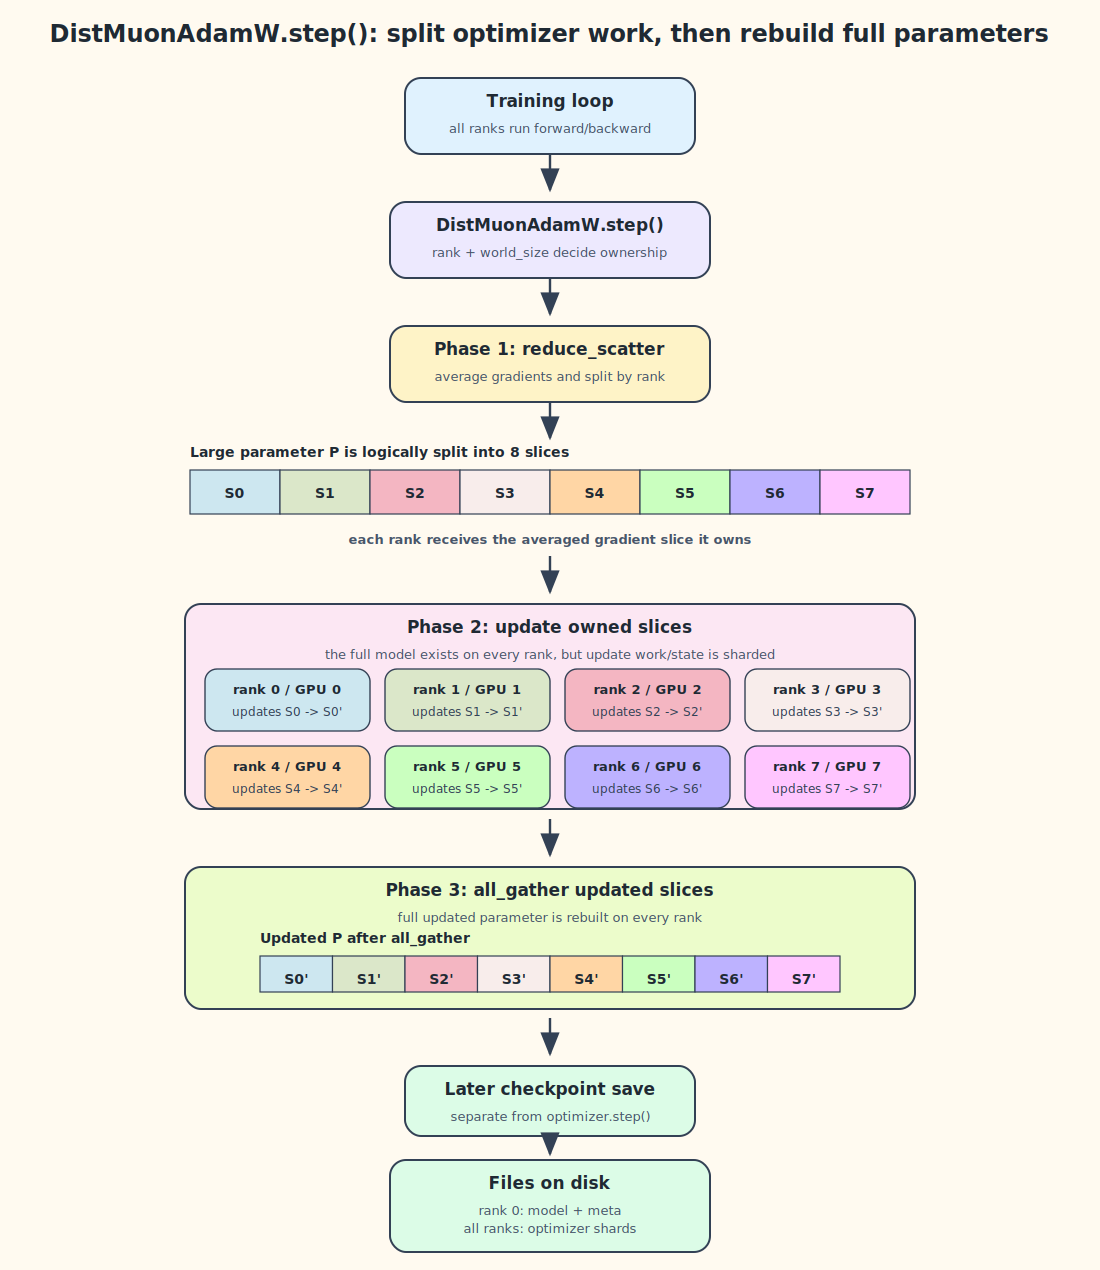

In [33]:
from IPython.display import SVG, display

def text(x, y, value, size=14, weight=400, anchor="middle", color="#1f2933"):
    return f'<text x="{x}" y="{y}" text-anchor="{anchor}" font-size="{size}" font-weight="{weight}" fill="{color}">{value}</text>'

def box(x, y, w, h, title, subtitle="", fill="#f8fafc", stroke="#334155"):
    parts = [f'<rect x="{x}" y="{y}" width="{w}" height="{h}" rx="16" fill="{fill}" stroke="{stroke}" stroke-width="2"/>']
    parts.append(text(x + w / 2, y + 29, title, size=17, weight=800))
    lines = [subtitle] if isinstance(subtitle, str) and subtitle else list(subtitle)
    for i, line in enumerate(lines):
        parts.append(text(x + w / 2, y + 55 + i * 18, line, size=13, color="#475569"))
    return "\n".join(parts)

def arrow_down(x, y1, y2):
    return f'<line x1="{x}" y1="{y1}" x2="{x}" y2="{y2}" stroke="#334155" stroke-width="2.4" marker-end="url(#arrow)"/>'

def slice_bar(x, y, labels, title, colors, w=720, h=44):
    chip_w = w / len(labels)
    parts = [text(x, y - 13, title, size=14, weight=800, anchor="start")]
    for i, label in enumerate(labels):
        cx = x + i * chip_w
        parts.append(f'<rect x="{cx}" y="{y}" width="{chip_w}" height="{h}" fill="{colors[i]}" stroke="#334155" stroke-width="1.2"/>')
        parts.append(text(cx + chip_w / 2, y + 28, label, size=14, weight=800))
    return "\n".join(parts)

def rank_grid(x, y, colors):
    parts = []
    card_w, card_h, gap = 165, 62, 15
    for i in range(8):
        col = i % 4
        row = i // 4
        cx = x + col * (card_w + gap)
        cy = y + row * (card_h + gap)
        parts.append(f'<rect x="{cx}" y="{cy}" width="{card_w}" height="{card_h}" rx="12" fill="{colors[i]}" stroke="#334155" stroke-width="1.4"/>')
        parts.append(text(cx + card_w / 2, cy + 25, f"rank {i} / GPU {i}", size=13, weight=800))
        parts.append(text(cx + card_w / 2, cy + 47, f"updates S{i} -> S{i}'", size=12, color="#334155"))
    return "\n".join(parts)

colors = ["#cde7f0", "#dbe7c9", "#f4b6c2", "#f8edeb", "#ffd6a5", "#caffbf", "#bdb2ff", "#ffc6ff"]
before = [f"S{i}" for i in range(8)]
after = [f"S{i}'" for i in range(8)]

svg = f'''
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 1100 1270" width="100%" style="max-width:1100px; font-family:-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif;">
  <defs>
    <marker id="arrow" markerWidth="10" markerHeight="8" refX="9" refY="4" orient="auto">
      <path d="M0,0 L10,4 L0,8 Z" fill="#334155"/>
    </marker>
  </defs>
  <rect x="0" y="0" width="1100" height="1270" fill="#fffaf0"/>
  {text(550, 42, 'DistMuonAdamW.step(): split optimizer work, then rebuild full parameters', size=24, weight=900)}

  {box(405, 78, 290, 76, 'Training loop', 'all ranks run forward/backward', '#e0f2fe')}
  {arrow_down(550, 154, 190)}
  {box(390, 202, 320, 76, 'DistMuonAdamW.step()', 'rank + world_size decide ownership', '#ede9fe')}
  {arrow_down(550, 278, 314)}
  {box(390, 326, 320, 76, 'Phase 1: reduce_scatter', 'average gradients and split by rank', '#fef3c7')}

  {arrow_down(550, 402, 438)}
  {slice_bar(190, 470, before, 'Large parameter P is logically split into 8 slices', colors)}
  {text(550, 544, 'each rank receives the averaged gradient slice it owns', size=13, weight=700, color='#475569')}

  {arrow_down(550, 556, 592)}
  {box(185, 604, 730, 205, 'Phase 2: update owned slices', 'the full model exists on every rank, but update work/state is sharded', '#fce7f3')}
  {rank_grid(205, 669, colors)}

  {arrow_down(550, 819, 855)}
  {box(185, 867, 730, 142, 'Phase 3: all_gather updated slices', 'full updated parameter is rebuilt on every rank', '#ecfccb')}
  {slice_bar(260, 956, after, 'Updated P after all_gather', colors, w=580, h=36)}

  {arrow_down(550, 1018, 1054)}
  {box(405, 1066, 290, 70, 'Later checkpoint save', 'separate from optimizer.step()', '#dcfce7')}
  {arrow_down(550, 1136, 1154)}
  {box(390, 1160, 320, 92, 'Files on disk', ['rank 0: model + meta', 'all ranks: optimizer shards'], '#dcfce7')}
</svg>
'''

display(SVG(svg))

## Step 9. Checkpoints: Rank 0 Saves Model, Every Rank Saves Optimizer State

Checkpoint saving is a separate action after training steps have updated and synchronized the model in memory.

[`save_checkpoint(...)`](../nanochat/checkpoint_manager.py#L42-L59) behaves like this:

```python
if rank == 0:
    save model_<step>.pt
    save meta_<step>.json

if optimizer_data is not None:
    save optim_<step>_rank{rank}.pt
```

So for an 8-GPU training run:

```text
model_005568.pt          one full model file, rank 0 only
meta_005568.json         one metadata file, rank 0 only
optim_005568_rank0.pt    optimizer shard for rank 0
...
optim_005568_rank7.pt    optimizer shard for rank 7
```

For inference/chat, you need model + metadata + tokenizer. For exact training resume, you also need the optimizer shard for every rank.

Resume also needs to know where the dataloader was, otherwise training could restart from the wrong place in the dataset.

In [34]:
checkpoint_dir = artifact_root / "base_checkpoints" / "d24"
if checkpoint_dir.exists():
    for path in sorted(checkpoint_dir.iterdir()):
        print(path.name)
else:
    print(f"No local copied-back checkpoint directory found: {checkpoint_dir}")

meta_005568.json
model_005568.pt
optim_005568_rank0.pt
optim_005568_rank1.pt
optim_005568_rank2.pt
optim_005568_rank3.pt
optim_005568_rank4.pt
optim_005568_rank5.pt
optim_005568_rank6.pt
optim_005568_rank7.pt


## Step 10. Resume Needs Dataloader State Too

The model and optimizer are not the only state. Base training also saves `dataloader_state_dict` in metadata.

In [`scripts/base_train.py`](../scripts/base_train.py#L476-L499), metadata includes:

```python
"dataloader_state_dict": dataloader_state_dict,
"loop_state": {
    "min_val_bpb": min_val_bpb,
    "smooth_train_loss": smooth_train_loss,
    "total_training_time": total_training_time,
}
```

The dataloader state records which parquet file and row group the run had reached. That is why resume can continue approximately from the same data position instead of starting over.

Training is not the only distributed phase. Evaluation uses ranks too, but combines metric totals instead of optimizer updates.

In [35]:
if base_meta is None:
    print("No base metadata found.")
else:
    print("step:", base_meta["step"])
    print("dataloader_state_dict:")
    print(json.dumps(base_meta["dataloader_state_dict"], indent=2))
    print("loop_state:")
    print(json.dumps(base_meta["loop_state"], indent=2))

step: 5568
dataloader_state_dict:
{
  "pq_idx": 122,
  "rg_idx": 80,
  "epoch": 1
}
loop_state:
{
  "min_val_bpb": 0.7181699883094174,
  "smooth_train_loss": 2.337961395641675,
  "total_training_time": 10303.380177736282
}


## Step 11. Evaluation Also Uses Ranks And Reductions

Distributed evaluation usually follows this pattern:

```text
each rank evaluates a slice of examples
each rank gets local counts/loss totals
dist.all_reduce(...) combines totals across ranks
rank 0 prints/logs final metric
```

Examples:

- [`nanochat/loss_eval.py`](../nanochat/loss_eval.py#L57-L58) all-reduces BPB totals.
- [`nanochat/core_eval.py`](../nanochat/core_eval.py#L247-L259) distributes CORE examples.
- [`scripts/chat_eval.py`](../scripts/chat_eval.py#L31-L73) distributes chat benchmark examples.
- [`scripts/chat_rl.py`](../scripts/chat_rl.py#L233-L236) all-reduces `pass@k` counts.

So distributed training and distributed evaluation use the same rank idea, but evaluation reduces metrics instead of optimizer gradients.

The logs are where all of these ideas become visible during a real run.

## Step 12. How To Read The Distributed Training Logs

Your RunPod logs contain the core distributed facts. The important lines look like:

```text
Distributed world size: 8
Tokens / micro-batch / rank: 16 x 2048 = 32,768
Tokens / micro-batch: 262,144
Total batch size 1,048,576 => gradient accumulation steps: 4
step ... | dt: ... | tok/sec: ... | bf16_mfu: ...
```

Interpretation:

- `world size`: number of ranks/processes/GPU workers.
- `tokens / micro-batch / rank`: work done by one GPU in one forward/backward.
- `tokens / micro-batch`: work done by all GPUs together in one forward/backward.
- `gradient accumulation steps`: how many forward/backward passes happen before one optimizer update.
- `tok/sec`: global training throughput, based on `total_batch_size / dt`.
- `MFU`: estimated hardware utilization.

These log numbers also explain why a single-GPU run can be logically similar but much slower.

In [36]:
log_paths = [artifact_root / "speedrun.log", artifact_root / "sft_retry.log"]
patterns = [
    "Distributed world size",
    "Tokens / micro-batch / rank",
    "Tokens / micro-batch:",
    "Total batch size",
]

for log_path in log_paths:
    if not log_path.exists():
        continue
    print(f"--- {log_path.relative_to(artifact_root)} ---")
    found = {pattern: False for pattern in patterns}
    training_line = None
    for line in log_path.read_text(errors="replace").splitlines():
        clean = re.sub(r"\x1b\[[0-9;]*m", "", line)
        for pattern in patterns:
            if pattern in clean and not found[pattern]:
                print(clean)
                found[pattern] = True
        if training_line is None and re.search(r"step 0*4[0-9].*tok/sec", clean):
            training_line = clean
        if all(found.values()) and training_line is not None:
            break
    if training_line:
        print(training_line)
    print()

--- speedrun.log ---
2026-05-27 22:03:55,999 - nanochat.common - INFO - Distributed world size: 8
Tokens / micro-batch / rank: 16 x 2048 = 32,768
Tokens / micro-batch: 262,144
Total batch size 1,048,576 => gradient accumulation steps: 4
step 00040/05568 (0.72%) | loss: 5.891433 | lrm: 1.00 | dt: 1871.91ms | tok/sec: 560,163 | bf16_mfu: 33.81 | epoch: 1 pq: 1 rg: 0 | total time: 0.93m | eta: 171.7m

--- sft_retry.log ---
2026-05-28 01:23:12,832 - nanochat.common - INFO - Distributed world size: 8
Tokens / micro-batch / rank: 16 x 2048 = 32,768
Tokens / micro-batch: 262,144
Total batch size 1,048,576 => gradient accumulation steps: 4
step 00040 (8.28%) | loss: 1.096263 | lrm: 1.00 | dt: 1267.61ms | tok/sec: 827,206 | mfu: 49.93 | epoch: 1 | total time: 0.63m



## Step 13. Why Single GPU Can Produce Similar Results, Just Slower

The README says the code can run on one GPU by omitting `torchrun`, but it will take much longer. The reason is the batch math.

With 8 GPUs:

```text
world_tokens_per_fwdbwd = 16 * 2048 * 8 = 262,144
grad_accum_steps = 1,048,576 / 262,144 = 4
```

With 1 GPU and the same per-GPU batch:

```text
world_tokens_per_fwdbwd = 16 * 2048 * 1 = 32,768
grad_accum_steps = 1,048,576 / 32,768 = 32
```

So one optimizer update can represent the same total token batch, but it needs 32 micro-steps instead of 4. That is why the result can be similar while wall-clock time is much worse.

## Step 14. Keep This Mental Model

Distributed nanochat training is not a different kind of training. It is the same training loop split across ranks.

```text
torchrun
  creates ranks and env vars

compute_init
  maps rank -> CUDA device
  initializes NCCL process group

dataloader/task iterator
  gives each rank different data

training loop
  each rank runs forward/backward on its own micro-batches
  gradient accumulation reaches total_batch_size

DistMuonAdamW
  synchronizes gradients/updates
  shards optimizer state

checkpoint_manager
  rank 0 saves model/meta
  all ranks save optimizer shards
```

The source files to read next are:

- [`runs/speedrun.sh`](../runs/speedrun.sh): where the 8-GPU commands are launched.
- [`nanochat/common.py`](../nanochat/common.py): rank/device/process-group setup.
- [`nanochat/dataloader.py`](../nanochat/dataloader.py): parquet row-group sharding.
- [`scripts/base_train.py`](../scripts/base_train.py): global batch math, gradient accumulation, saving.
- [`scripts/chat_sft.py`](../scripts/chat_sft.py): conversation sharding and the same batch math.
- [`nanochat/gpt.py`](../nanochat/gpt.py#L374-L414): choosing `DistMuonAdamW` when distributed.
- [`nanochat/optim.py`](../nanochat/optim.py): distributed optimizer synchronization and state sharding.
- [`nanochat/checkpoint_manager.py`](../nanochat/checkpoint_manager.py): rank-aware model and optimizer checkpoint files.